
Analizando la relación entre 'price' y 'host_response_rate'...
  Modelo Polinomial - R^2: 0.0051, Parámetros: [ 5.04023591e-09 -6.20578454e-05  9.81075449e-01]


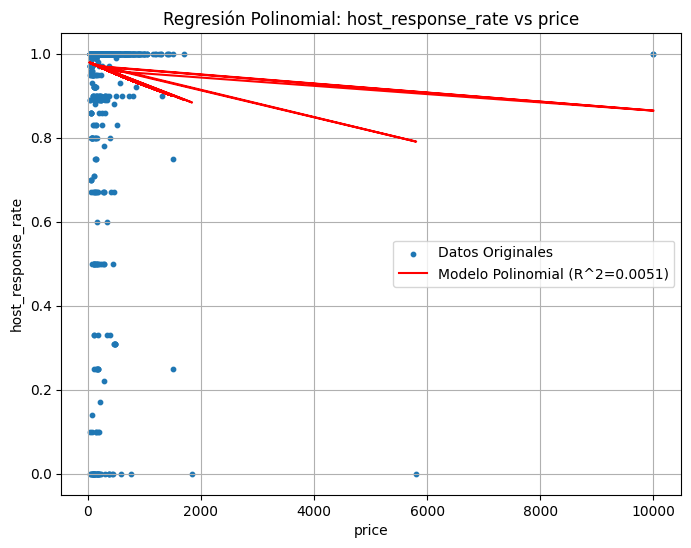

  Modelo Exponencial - R^2: 0.0040, Parámetros: [ 2.49265315e-01 -1.85707248e-04  7.28760412e-01]


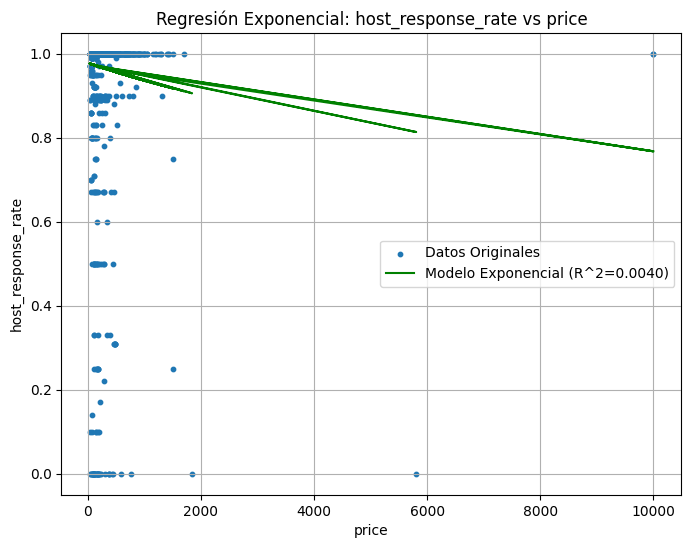


Analizando la relación entre 'price' y 'host_acceptance_rate'...
  Modelo Polinomial - R^2: 0.0004, Parámetros: [ 3.27352553e-09 -3.03732994e-05  8.76892132e-01]


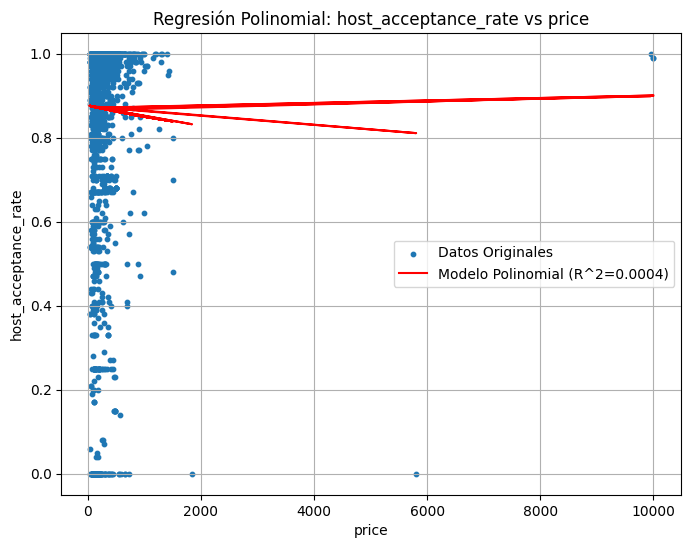

  Modelo Exponencial - R^2: 0.0001, Parámetros: [ 5.77247108e-02 -2.10706417e-04  8.15708936e-01]


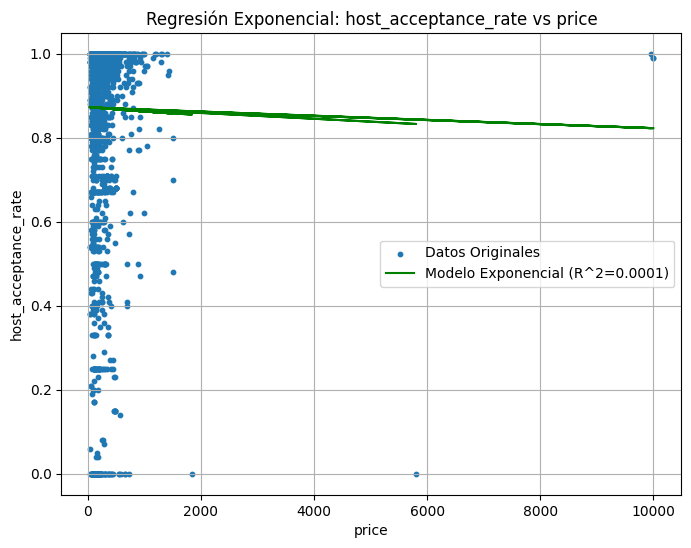


Analizando la relación entre 'price' y 'host_total_listings_count'...
  Modelo Polinomial - R^2: 0.0106, Parámetros: [-1.13704548e-05  1.08855942e-01  7.40949524e+00]


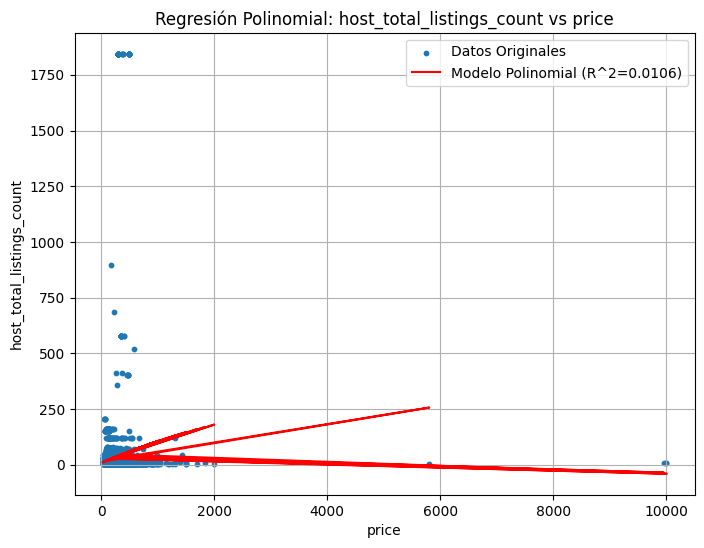

  Modelo Exponencial - R^2: 0.0019, Parámetros: [ 2.96752590e+05  6.95158348e-08 -2.96728305e+05]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


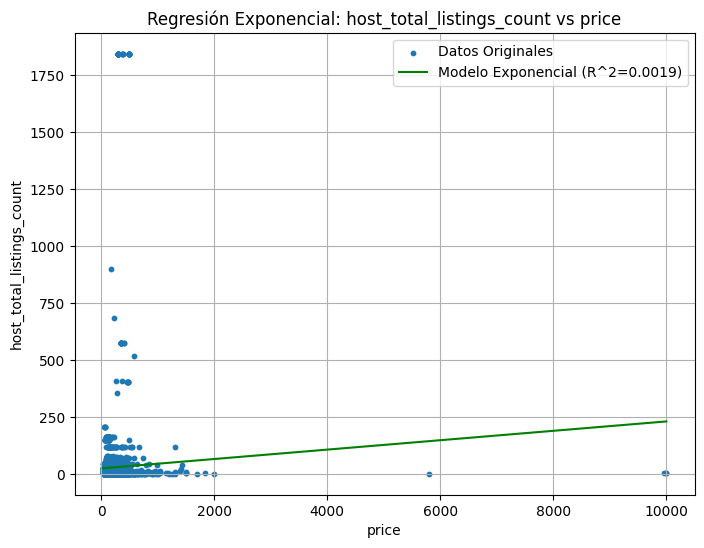


Analizando la relación entre 'price' y 'accommodates'...
  Modelo Polinomial - R^2: 0.4328, Parámetros: [-9.58108885e-07  9.43763888e-03  1.96301188e+00]


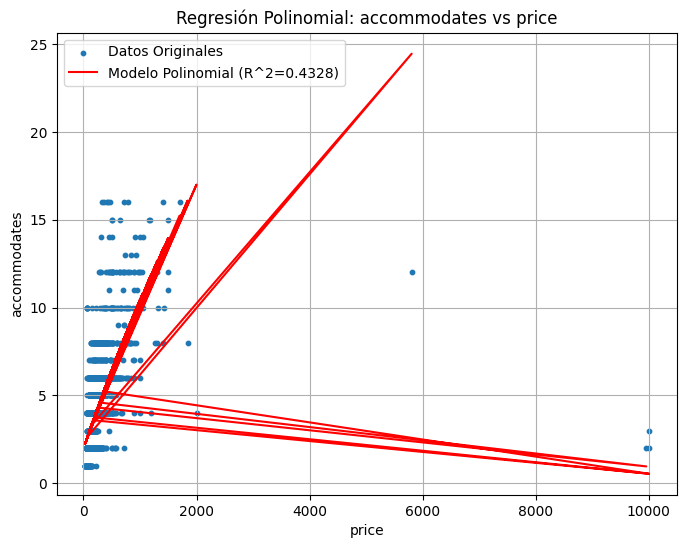

  Modelo Exponencial - R^2: 0.0985, Parámetros: [ 6.82759813e+04  2.93739576e-08 -6.82725963e+04]


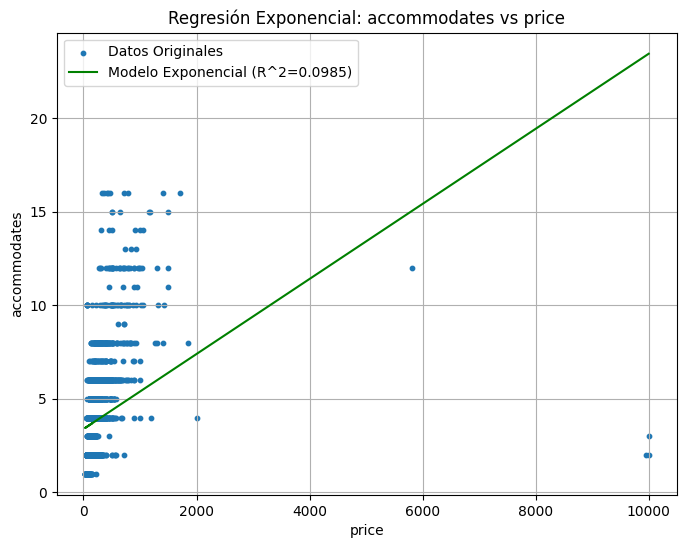


Analizando la relación entre 'price' y 'reviews_per_month'...
  Modelo Polinomial - R^2: 0.0209, Parámetros: [ 1.60194705e-07 -1.73270980e-03  2.23440398e+00]


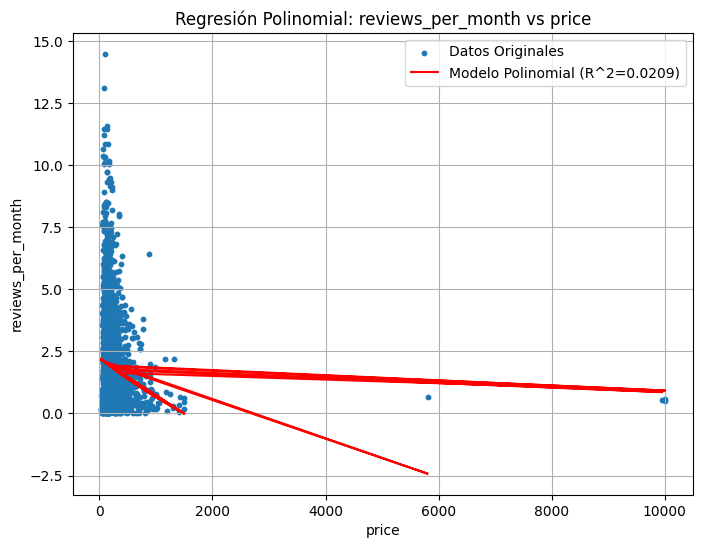

  Modelo Exponencial - R^2: 0.0226, Parámetros: [ 2.13146591e+00 -1.33980612e-03  2.36488237e-01]


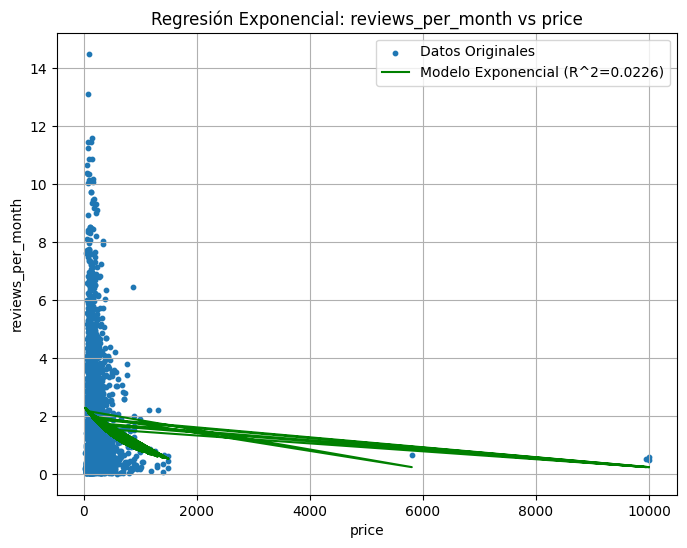

Tabla de Coeficientes de Determinación
                           Polinomial  Exponencial
host_response_rate           0.005133     0.004047
host_acceptance_rate         0.000375     0.000102
host_total_listings_count    0.010569     0.001919
accommodates                 0.432781     0.098516
reviews_per_month            0.020947     0.022553


In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


df = pd.read_csv('listings.csv')

# Variables objetivo a analizar
variables_objetivo = ['host_response_rate', 'host_acceptance_rate',
                       'host_total_listings_count', 'accommodates',
                       'reviews_per_month']
variable_independiente = 'price'

# Modelo no lineal a utilizar (Polinomial)
def modelo_polinomial(x, a, b, c):
    return a * x**2 + b * x + c

# Modelo no lineal a utilizar (Exponencial)
def modelo_exponencial(x, a, b, c):
    return a * np.exp(b * x) + c

resultados = {}

for var_objetivo in variables_objetivo:
    print(f"\nAnalizando la relación entre '{variable_independiente}' y '{var_objetivo}'...")

    # Eliminar filas con valores nulos en las variables de interés para el análisis actual
    df_analisis = df.dropna(subset=[variable_independiente, var_objetivo]).copy()

    # Limpiar la columna de precio
    df_analisis[variable_independiente] = df_analisis[variable_independiente].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype('float')

    # Limpiar columnas con formato de porcentaje si es necesario
    if var_objetivo in ['host_response_rate', 'host_acceptance_rate']:
        df_analisis[var_objetivo] = df_analisis[var_objetivo].str.rstrip('%').astype('float') / 100.0

    x_data = df_analisis[variable_independiente]
    y_data = df_analisis[var_objetivo]

    resultados[var_objetivo] = {}

    # --- Modelo Polinomial ---
    parametros_poli, _ = curve_fit(modelo_polinomial, x_data, y_data, p0=[1, 1, 1], maxfev=5000)
    y_pred_poli = modelo_polinomial(x_data, *parametros_poli)
    r2_poli = r2_score(y_data, y_pred_poli)
    resultados[var_objetivo]['Polinomial'] = {'R2': r2_poli, 'parametros': parametros_poli}

    print(f"  Modelo Polinomial - R^2: {r2_poli:.4f}, Parámetros: {parametros_poli}")

    # Graficar (opcional)
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, label='Datos Originales', s=10)
    plt.plot(x_data, y_pred_poli, color='red', label=f'Modelo Polinomial (R^2={r2_poli:.4f})')
    plt.xlabel(variable_independiente)
    plt.ylabel(var_objetivo)
    plt.title(f'Regresión Polinomial: {var_objetivo} vs {variable_independiente}')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Modelo Exponencial ---
    parametros_exp, _ = curve_fit(modelo_exponencial, x_data, y_data, p0=[1, -0.001, 1], maxfev=5000)
    y_pred_exp = modelo_exponencial(x_data, *parametros_exp)
    r2_exp = r2_score(y_data, y_pred_exp)
    resultados[var_objetivo]['Exponencial'] = {'R2': r2_exp, 'parametros': parametros_exp}

    print(f"  Modelo Exponencial - R^2: {r2_exp:.4f}, Parámetros: {parametros_exp}")

    # Graficar (opcional)
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, label='Datos Originales', s=10)
    plt.plot(x_data, y_pred_exp, color='green', label=f'Modelo Exponencial (R^2={r2_exp:.4f})')
    plt.xlabel(variable_independiente)
    plt.ylabel(var_objetivo)
    plt.title(f'Regresión Exponencial: {var_objetivo} vs {variable_independiente}')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Creación de la Tabla de Resultados ---
print("Tabla de Coeficientes de Determinación")
tabla_r2 = {}
for var, modelos in resultados.items():
    tabla_r2[var] = {}
    for modelo, datos in modelos.items():
        tabla_r2[var][modelo] = datos.get('R2', np.nan)

df_tabla_r2 = pd.DataFrame(tabla_r2).T
print(df_tabla_r2)
